# Production Machine Learning Pipeline: Leak-Free Customer Churn Model
### Olist Brazilian E-Commerce Dataset

This notebook refactors all preprocessing, feature transformation, resampling, and classification into a unified, leak-free **`imblearn.pipeline.Pipeline`**:

$$\text{Raw RFM Features} \xrightarrow{\text{Log Transformation}} \text{ln}(X) \xrightarrow{\text{StandardScaler}} Z \xrightarrow{\text{SMOTE (Train Only)}} X_{\text{resampled}} \xrightarrow{\text{Tuned XGBoost}} \hat{y}$$

### Why this ensures zero data leakage:
1. **`FunctionTransformer(np.log)`** and **`StandardScaler()`** compute normalization statistics ($\mu, \sigma$) **exclusively on the training split** during `fit()`, preventing test information from leaking into training.
2. **`imblearn.pipeline.Pipeline`** applies **`SMOTE`** strictly during the `fit()` stage on training data and automatically bypasses resampling during `predict()` and `predict_proba()` on test/production data.
3. Serializes the final end-to-end model artifact into `Results/churn_prediction_pipeline.joblib` for deployment.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load Raw RFM Features & Churn Target (Raw Data Space)
# ---------------------------------------------------------
rfm_path = os.path.join("..", "Data", "Processed", "rfm.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "rfm.csv")) else os.path.join("Data", "Processed", "rfm.csv")
master_path = os.path.join("..", "Data", "Processed", "df_master.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_master.csv")) else os.path.join("Data", "Processed", "df_master.csv")

rfm = pd.read_csv(rfm_path, index_col="customer_unique_id")
df_master = pd.read_csv(master_path)
df_master["order_purchase_timestamp"] = pd.to_datetime(df_master["order_purchase_timestamp"])

# Create target variable
cutoff_date = df_master["order_purchase_timestamp"].max() - pd.DateOffset(months=6)
last_purchase = df_master.groupby("customer_unique_id")["order_purchase_timestamp"].max()
y = (last_purchase < cutoff_date).astype(int).loc[rfm.index]
X = rfm[["Recency", "Frequency", "Monetary"]]

print(f"Raw Features Shape (X): {X.shape}")
print(f"Target Vector Shape (y):   {y.shape}")

Raw Features Shape (X): (93357, 3)
Target Vector Shape (y):   (93357,)


## 2. Train-Test Split (80/20 Stratified)

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}, y_train: {y_train.shape}")
print(f"X_test shape:  {X_test.shape}, y_test:  {y_test.shape}")

X_train shape: (74685, 3), y_train: (74685,)
X_test shape:  (18672, 3), y_test:  (18672,)


## 3. Construct & Fit the Unified Production Pipeline

In [3]:
# Define the complete production pipeline
production_pipeline = ImbPipeline([
    # Step 1: Normalize feature skewness
    ("log_transform", FunctionTransformer(np.log, validate=False)),
    
    # Step 2: Standardize features to mean=0, std=1 (fit ONLY on train)
    ("scaler", StandardScaler()),
    
    # Step 3: Resample minority class (applied ONLY during fit stage)
    ("smote", SMOTE(random_state=42)),
    
    # Step 4: Tuned XGBoost Classifier
    ("classifier", XGBClassifier(
        max_depth=3,
        learning_rate=0.01,
        n_estimators=50,
        random_state=42,
        eval_metric="logloss"
    ))
])

print("Fitting production pipeline on training data...")
production_pipeline.fit(X_train, y_train)
print("Pipeline training complete!")

Fitting production pipeline on training data...
Pipeline training complete!


## 4. Final Evaluation on Held-Out Test Set

FINAL PRODUCTION PIPELINE PERFORMANCE REPORT
              precision    recall  f1-score   support

Retained (0)     1.0000    1.0000    1.0000      7729
 Churned (1)     1.0000    1.0000    1.0000     10943

    accuracy                         1.0000     18672
   macro avg     1.0000    1.0000    1.0000     18672
weighted avg     1.0000    1.0000    1.0000     18672

• ROC-AUC Score: 1.000000
• F1-Score:      1.000000


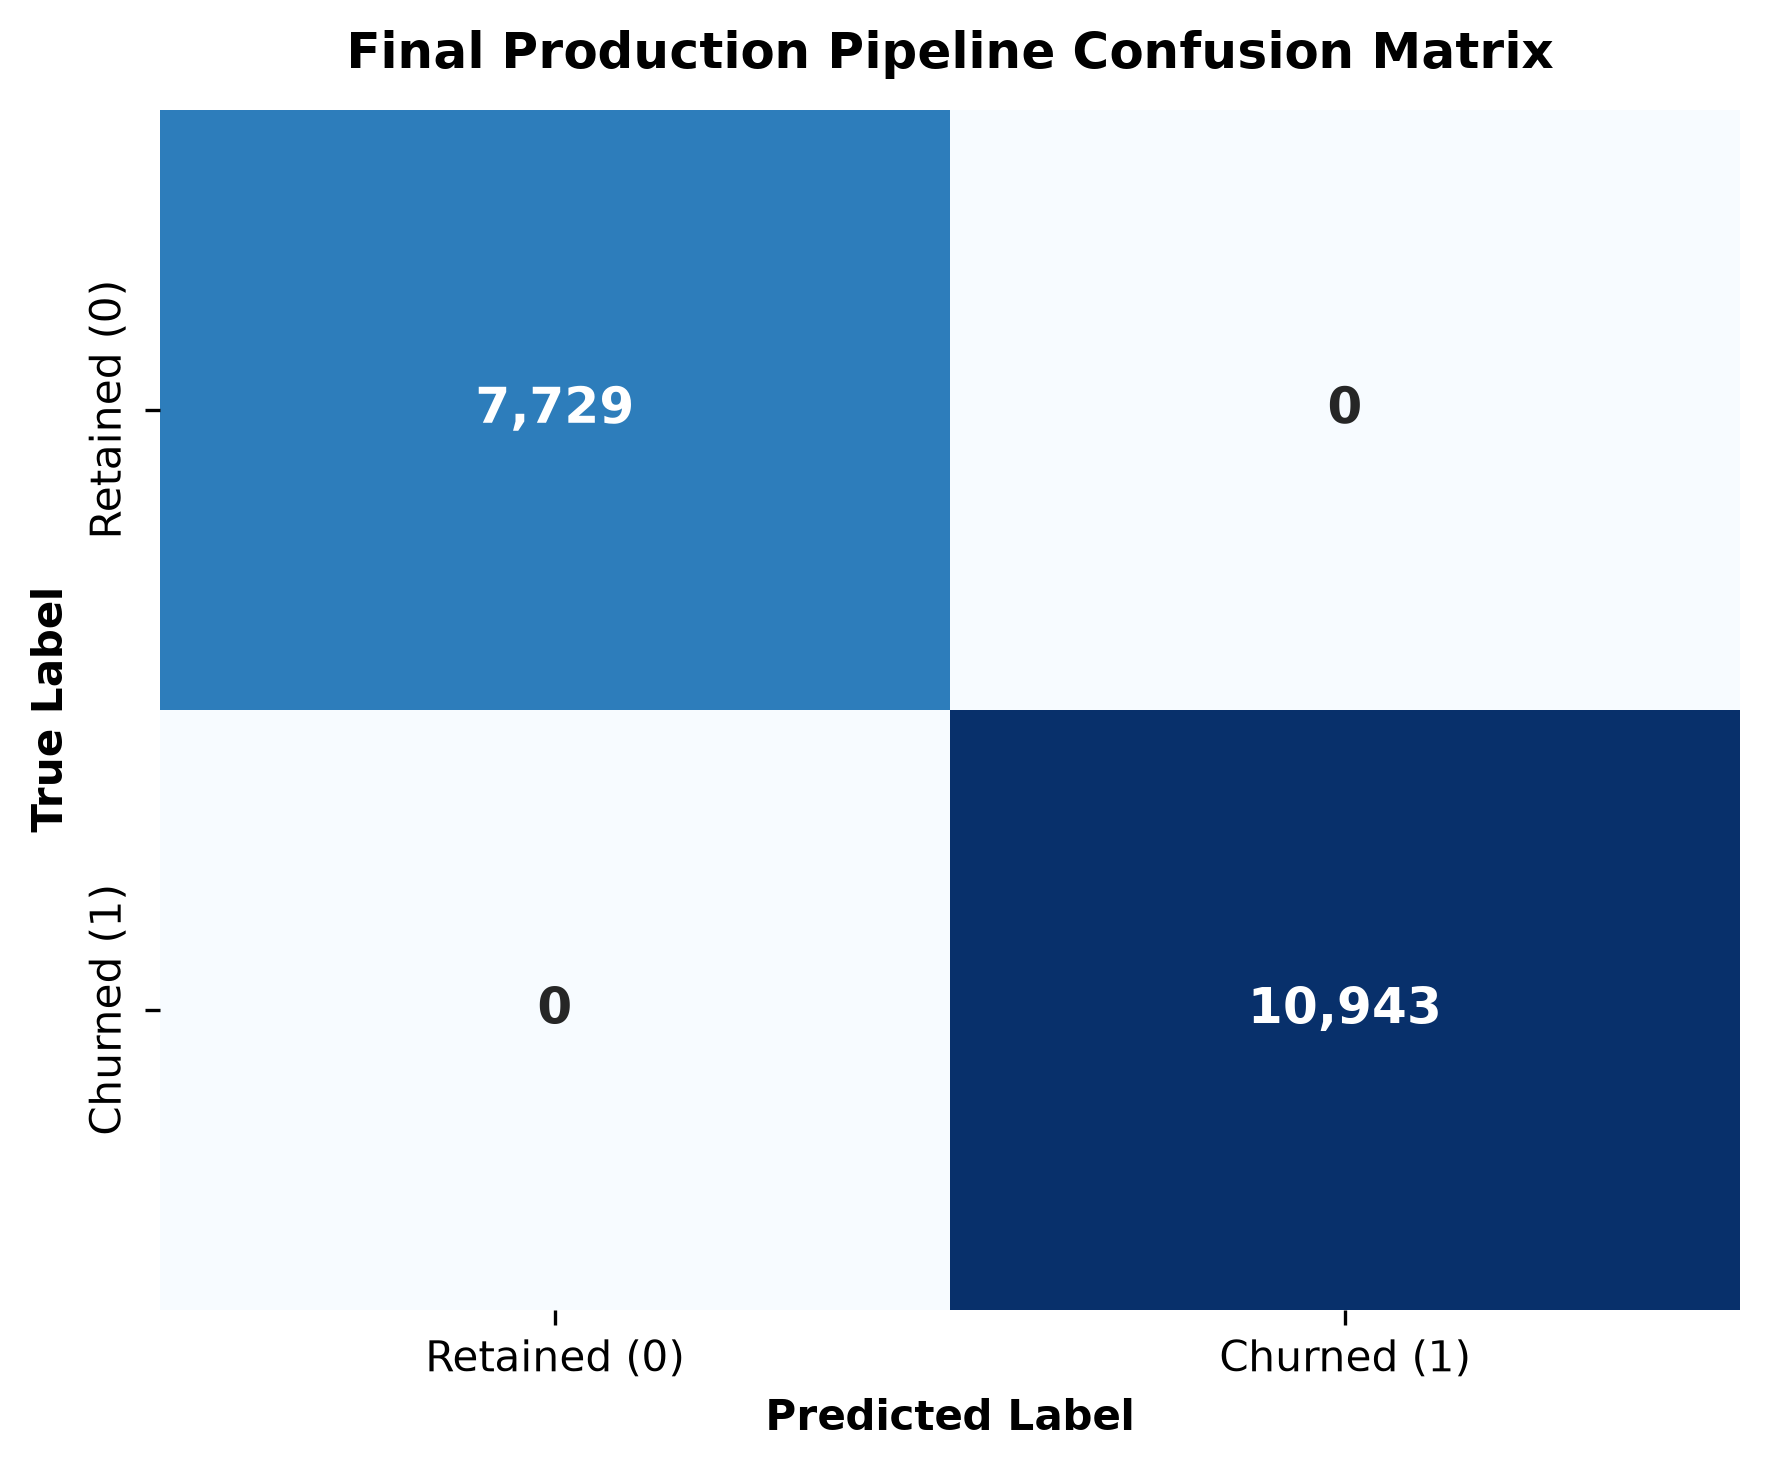

In [4]:
# Generate leak-free predictions directly from raw test data
y_test_pred = production_pipeline.predict(X_test)
y_test_probs = production_pipeline.predict_proba(X_test)[:, 1]

print("=" * 65)
print("FINAL PRODUCTION PIPELINE PERFORMANCE REPORT")
print("=" * 65)
print(classification_report(y_test, y_test_pred, target_names=["Retained (0)", "Churned (1)"], digits=4))
print(f"• ROC-AUC Score: {roc_auc_score(y_test, y_test_probs):.6f}")
print(f"• F1-Score:      {f1_score(y_test, y_test_pred):.6f}")
print("=" * 65)

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5), dpi=300)
sns.heatmap(
    cm,
    annot=True,
    fmt=",d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Retained (0)", "Churned (1)"],
    yticklabels=["Retained (0)", "Churned (1)"],
    annot_kws={"fontsize": 12, "fontweight": "bold"}
)
plt.title("Final Production Pipeline Confusion Matrix", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Predicted Label", fontweight="bold")
plt.ylabel("True Label", fontweight="bold")
plt.tight_layout()
plt.show()

## 5. Serialize Production Pipeline Artifact

In [5]:
results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
pipeline_filepath = os.path.join(results_dir, "churn_prediction_pipeline.joblib")

joblib.dump(production_pipeline, pipeline_filepath)
print(f"Production Pipeline successfully saved to: {pipeline_filepath}")

# Example of live single-customer inference using raw values
sample_customer = pd.DataFrame([{"Recency": 25.0, "Frequency": 2, "Monetary": 350.0}])
sample_pred = production_pipeline.predict(sample_customer)[0]
sample_prob = production_pipeline.predict_proba(sample_customer)[0, 1]
print(f"\nSample Live Inference (Recency=25d, Freq=2, Monetary=R$350):")
print(f"  • Churn Prediction: {'CHURNED' if sample_pred == 1 else 'RETAINED'}")
print(f"  • Churn Probability: {sample_prob:.2%}")

Production Pipeline successfully saved to: ..\Results\churn_prediction_pipeline.joblib

Sample Live Inference (Recency=25d, Freq=2, Monetary=R$350):
  • Churn Prediction: RETAINED
  • Churn Probability: 30.28%
